In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d


In [4]:
# read the file: C:\Users\Sepehr\Desktop\LLM-RL\create_figures\outputs\agent_intervention_matrix_20_20_10_0.25.npy
agent_intervention_matrix = np.load('outputs/agent_intervention_matrix_20_20_10_0.25.npy')
agent_intervention_matrix.shape

(10, 20, 20, 20, 2)

In [81]:
# print(agent_intervention_matrix[0, , 3, 9])


SyntaxError: invalid syntax (1007112607.py, line 1)

In [22]:
for i in range(10):
    for j in range(20):
        for k in range(20):
            for l in range(20):
                pair = agent_intervention_matrix[i, j, k, l]
                # drop nan values
                if np.isnan(pair).any():
                    continue
                if pair[0] == 1 or pair[1] == 1:
                    print(i, j, k, l, pair)


In [38]:
# get the number of [0, 0], [0, 2], [2, 0], [2, 2] pairs in each round and each time step (first two dimentions)
all_data = {}
for i in range(10):
    for j in range(20):
        intervention_00 = int(np.sum(agent_intervention_matrix[i, j] == [0, 0]))
        intervention_02_20 = int(np.sum(agent_intervention_matrix[i, j] == [0, 2]) + np.sum(agent_intervention_matrix[i, j] == [2, 0]))
        intervention_22 = int(np.sum(agent_intervention_matrix[i, j] == [2, 2]))
        total_interventions = intervention_00 + intervention_02_20 + intervention_22
        if total_interventions == 0:
            continue
        print(i, j, intervention_00, intervention_02_20, intervention_22)
        all_data[(i, j)] = [round(intervention_00/total_interventions, 2), round(intervention_02_20/total_interventions, 2), round(intervention_22/total_interventions, 2)]
        # print the sum of all pairs in each round and each time step
    print(intervention_00 + intervention_02_20 + intervention_22)
all_data

0 2 16 152 136
0 3 14 152 138
0 4 0 152 152
0 5 0 152 152
0 6 0 152 152
0 7 0 152 152
0 8 0 152 152
0 9 0 152 152
0 10 0 152 152
0 11 0 152 152
0 12 0 152 152
0 13 0 152 152
0 14 0 152 152
0 15 0 152 152
0 16 0 152 152
0 17 0 152 152
0 18 0 152 152
0 19 0 152 152
304
1 2 10 164 154
1 3 4 164 160
1 4 6 164 158
1 5 0 164 164
1 6 0 164 164
1 7 0 164 164
1 8 0 164 164
1 9 0 164 164
1 10 0 164 164
1 11 0 164 164
1 12 0 164 164
1 13 0 164 164
1 14 0 164 164
1 15 0 164 164
1 16 0 164 164
1 17 0 164 164
1 18 0 164 164
1 19 0 164 164
328
2 2 28 176 148
2 3 14 176 162
2 4 2 176 174
2 5 0 176 176
2 6 0 176 176
2 7 0 176 176
2 8 0 176 176
2 9 0 176 176
2 10 0 176 176
2 11 0 176 176
2 12 0 176 176
2 13 0 176 176
2 14 0 176 176
2 15 0 176 176
2 16 0 176 176
2 17 0 176 176
2 18 0 176 176
2 19 0 176 176
352
3 2 30 224 194
3 3 32 224 192
3 4 18 224 206
3 5 10 224 214
3 6 10 224 214
3 7 0 224 224
3 8 0 224 224
3 9 0 224 224
3 10 0 224 224
3 11 0 224 224
3 12 0 224 224
3 13 0 224 224
3 14 0 224 224
3 15 

{(0, 2): [0.05, 0.5, 0.45],
 (0, 3): [0.05, 0.5, 0.45],
 (0, 4): [0.0, 0.5, 0.5],
 (0, 5): [0.0, 0.5, 0.5],
 (0, 6): [0.0, 0.5, 0.5],
 (0, 7): [0.0, 0.5, 0.5],
 (0, 8): [0.0, 0.5, 0.5],
 (0, 9): [0.0, 0.5, 0.5],
 (0, 10): [0.0, 0.5, 0.5],
 (0, 11): [0.0, 0.5, 0.5],
 (0, 12): [0.0, 0.5, 0.5],
 (0, 13): [0.0, 0.5, 0.5],
 (0, 14): [0.0, 0.5, 0.5],
 (0, 15): [0.0, 0.5, 0.5],
 (0, 16): [0.0, 0.5, 0.5],
 (0, 17): [0.0, 0.5, 0.5],
 (0, 18): [0.0, 0.5, 0.5],
 (0, 19): [0.0, 0.5, 0.5],
 (1, 2): [0.03, 0.5, 0.47],
 (1, 3): [0.01, 0.5, 0.49],
 (1, 4): [0.02, 0.5, 0.48],
 (1, 5): [0.0, 0.5, 0.5],
 (1, 6): [0.0, 0.5, 0.5],
 (1, 7): [0.0, 0.5, 0.5],
 (1, 8): [0.0, 0.5, 0.5],
 (1, 9): [0.0, 0.5, 0.5],
 (1, 10): [0.0, 0.5, 0.5],
 (1, 11): [0.0, 0.5, 0.5],
 (1, 12): [0.0, 0.5, 0.5],
 (1, 13): [0.0, 0.5, 0.5],
 (1, 14): [0.0, 0.5, 0.5],
 (1, 15): [0.0, 0.5, 0.5],
 (1, 16): [0.0, 0.5, 0.5],
 (1, 17): [0.0, 0.5, 0.5],
 (1, 18): [0.0, 0.5, 0.5],
 (1, 19): [0.0, 0.5, 0.5],
 (2, 2): [0.08, 0.5, 0.42],
 (2, 3

In [57]:
# show all data values with a key like (0, any)
for key, value in all_data.items():
    if key[1] == 5:
        print(key, value)

(0, 5) [0.0, 0.5, 0.5]
(1, 5) [0.0, 0.5, 0.5]
(2, 5) [0.0, 0.5, 0.5]
(3, 5) [0.02, 0.5, 0.48]
(4, 5) [0.0, 0.5, 0.5]
(5, 5) [0.0, 0.5, 0.5]
(6, 5) [0.0, 0.5, 0.5]
(7, 5) [0.0, 0.5, 0.5]
(8, 5) [0.01, 0.5, 0.49]
(9, 5) [0.03, 0.5, 0.47]


In [79]:
# now average the data over the first element of the tuple
average_data = {}
for key, value in all_data.items():
    if key[1] not in average_data:
        average_data[key[1]] = np.array(value)
    else:
        average_data[key[1]] += np.array(value)
for key in average_data:
    print(average_data[key])
    average_data[key] /= 10

# make the values of the dictionary a list
average_data = {key: value.tolist() for key, value in average_data.items()}
# round the values of the dictionary to 2 decimal points
average_data = {key: [round(value, 2) for value in value] for key, value in average_data.items()}
average_data

# add two more key, values to the data
# 0: [0, 0, 0]
# 1: [0, 0, 0]


[0.6 5.  4.4]
[0.41 5.   4.59]
[0.21 5.   4.79]
[0.06 5.   4.94]
[0.05 5.   4.95]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]


{2: [0.06, 0.5, 0.44],
 3: [0.04, 0.5, 0.46],
 4: [0.02, 0.5, 0.48],
 5: [0.01, 0.5, 0.49],
 6: [0.01, 0.5, 0.49],
 7: [0.0, 0.5, 0.5],
 8: [0.0, 0.5, 0.5],
 9: [0.0, 0.5, 0.5],
 10: [0.0, 0.5, 0.5],
 11: [0.0, 0.5, 0.5],
 12: [0.0, 0.5, 0.5],
 13: [0.0, 0.5, 0.5],
 14: [0.0, 0.5, 0.5],
 15: [0.0, 0.5, 0.5],
 16: [0.0, 0.5, 0.5],
 17: [0.0, 0.5, 0.5],
 18: [0.0, 0.5, 0.5],
 19: [0.0, 0.5, 0.5]}

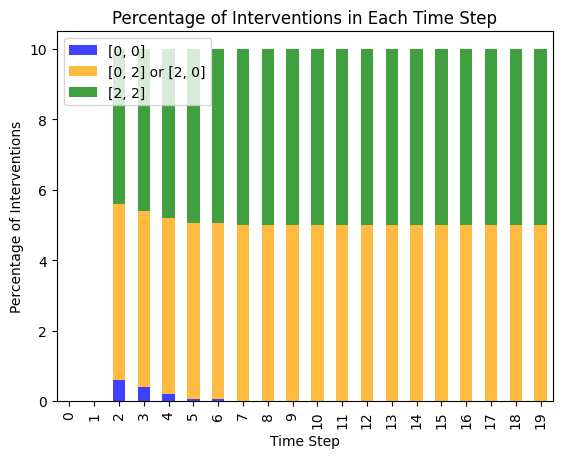

In [72]:
# draw a stacked bar plot
df = pd.DataFrame(average_data)
df = df.T
df.columns = ['[0, 0]', '[0, 2] or [2, 0]', '[2, 2]']
df.plot(kind='bar', stacked=True, color=['blue', 'orange', 'green'], alpha=0.75)
plt.xlabel('Time Step')
plt.ylabel('Percentage of Interventions')
plt.title('Percentage of Interventions in Each Time Step')
plt.show()